# Instalação das dependências

In [1]:
import numpy as np
import segyio
import matplotlib.pyplot as plt
import cv2
import pickle

import os
import sys
sys.path.append('..')

from scipy.ndimage import zoom
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import jaccard_score, f1_score, accuracy_score, recall_score
from sklearn.cluster import KMeans
from tqdm import tqdm

from atributos import Atributos
from superficie import Superficie
from utils import plot_Fernanda, plot_VJ, concatenate, subplot, segmenta, colore, resample
from hparams import drive_fernanda, drive_vittor

# Leitura dos arquivos CSV das superfícies
isso aqui é pra ler os horizontes q é a label dessa segmentacao, a classe Superficie vai contar a tabela de todas as seçoes anotadas e tem a funçao pra carregar a classe Atributos com a label daquela seçao especifica

In [2]:
barravelha = Superficie(os.path.join(drive_vittor, 'Horizontes/Topo_BV.csv'), shape = [3400, 3000], offsets = [27700, 45400])
camboriu = Superficie(os.path.join(drive_vittor, 'Horizontes/Topo_Embasamento.csv'), shape = [3400, 3000], offsets = [27700, 45400])
barravelha_Fernanda = Superficie(os.path.join(drive_fernanda, 'Horizontes/Topo_BV_Fernanda.csv'), shape = [1950, 1710], offsets = [2100, 3285])
camboriu_Fernanda = Superficie(os.path.join(drive_fernanda, 'Horizontes/Topo_Embasamento_Fernanda.csv'), shape = [1950, 1710], offsets = [2100, 3285])

# Crosslines/Inlines selecionadas para treino

In [3]:
sessoes_treino = [
    Atributos(
        path_sismica = os.path.join(drive_vittor, 'IL_45500.sgy'),
        path_velocidade = os.path.join(drive_vittor, 'IL_45500_vel.sgy'),
        resolucao = 6.25,
        deltaz = [12000, 0],
        linha_barravelha = barravelha.line(i = 45500, inline = 0, offset = False),
        linha_camboriu = camboriu.line(i = 45500, inline = 0, offset = False)
    ),
    # Atributos(
    #     path_sismica = os.path.join(drive_fernanda, 'CL_3822_Fernanda.sgy'),
    #     path_velocidade = os.path.join(drive_fernanda, 'CL_3822_Vel_Fernanda.sgy'),
    #     resolucao = 25,
    #     deltaz = [9955, 2000],
    #     linha_barravelha = barravelha_Fernanda.line(i = 3822 - 2100, inline = 1, offset = True),
    #     linha_camboriu = camboriu_Fernanda.line(i = 3822 - 2100, inline = 1, offset = True)
    # ),
]

sessao_controle_Vittor = [
    Atributos(
        path_sismica = os.path.join(drive_vittor, 'IL_45500.sgy'),
        path_velocidade = os.path.join(drive_vittor, 'IL_45500_vel.sgy'),
        resolucao = 6.25,
        deltaz = [12000, 0],
        linha_barravelha = barravelha.line(i = 45500, inline = 0, offset = False),
        linha_camboriu = camboriu.line(i = 45500, inline = 0, offset = False)
    ),
]

sessao_controle_Fernanda = [
    # Atributos(
    #     path_sismica = os.path.join(drive_fernanda, 'CL_3822_Fernanda.sgy'),
    #     path_velocidade = os.path.join(drive_fernanda, 'CL_3822_Vel_Fernanda.sgy'),
    #     resolucao = 25,
    #     deltaz = [9955, 2000],
    #     linha_barravelha = barravelha_Fernanda.line(i = 3822 - 2100, inline = 1, offset = True),
    #     linha_camboriu = camboriu_Fernanda.line(i = 3822 - 2100, inline = 1, offset = True)
    # ),
]

# atributos

In [4]:
'''
Vittor Javidan:
    Acredito que o problema descrito com o path já está resolvido, por conta dele ser colocado
    manualmente logo no início do arquivo, quando se instancia cada Crossline/Inline.
'''

for obj in tqdm(sessoes_treino):
    obj._complexo()
    obj._logaritmo()
    obj._coherence()
    obj._soterramento(marambaia = False) # soterramento é o yy
    obj._tecva()

for obj in tqdm(sessao_controle_Vittor):
    obj._complexo()
    obj._logaritmo()
    obj._coherence()
    obj._soterramento(marambaia = False) # soterramento é o yy
    obj._tecva()

for obj in tqdm(sessao_controle_Fernanda):
    obj._complexo()
    obj._logaritmo()
    obj._coherence()
    obj._soterramento(marambaia = False) # soterramento é o yy
    obj._tecva()

# como o path muda para cada seçao os atributos externos teria q fazer da forma chata :(, mas msm assim tem seçoes q n tem os atributos, entao vamos so com os de calculo msm
# crossline_3800.pimp = segyio.tools.cube(os.path.join(drive_fernanda, 'CL 3800/n tem por exemplo.sgy'))[0, :, :]
# ...

  0%|          | 0/1 [00:00<?, ?it/s]e:\TG\Vittor\Treinos\4 (Vittor, Sem soterramento)\atributos.py:48: RuntimeWarning: invalid value encountered in scalar divide
  return vals.max() / vals.sum()
e:\TG\Vittor\Treinos\4 (Vittor, Sem soterramento)\atributos.py:54: RuntimeWarning: invalid value encountered in scalar divide
  sembl = cov.sum() / cov.diagonal().sum()
100%|██████████| 1/1 [01:17<00:00, 77.67s/it]
0it [00:00, ?it/s]


# tarefa
> Eu e a Mari reunimos pra escolher quais são as melhores seções pra entrar no artigo do random forest + kmeans:
> 
> 
> Crosslines 4022, 3822 (treino), 3800, 3722, 3600, 3300, 2700
> Inline: 4330
>

# Treinando o modelo

In [5]:
def mistura(obj):
    return [
        obj.X, 
        obj.envelope, obj.fase, obj.freq, obj.sweetness, # complexo
        obj.log, # logaritmo
        obj.gersztenkorn, obj.sobel, obj.marfurt, # coherence
        # obj.yy, # soterramento
        obj.tecva, obj.rms, # tecva
        obj.velocidade_rs, # velocidade
    ]

n_features = 12
X_trn = np.zeros(shape = (0, n_features))
Y_trn = np.zeros(shape = (0, ))
# a ideia é ir iterando nos objetos e concatenando
for obj in sessoes_treino:
    X_trn = np.vstack((X_trn, concatenate(mistura(obj))))
    Y_trn = np.hstack((Y_trn, obj.segmentado.ravel()))
X_trn.shape, Y_trn.shape # pode ver q o dataset é tres vezes maior

((2271135, 12), (2271135,))

In [6]:
# treinando
clf = RandomForestClassifier(max_depth = X_trn.shape[1], random_state = 0)
clf.fit(X_trn, Y_trn)
# vou salvar o modelo para o caso de vc querer dps
with open('./modelo.pkl', 'wb') as out: 
    pickle.dump(clf, out)

# Utilizando o modelo

Carregando o modelo treinado

In [7]:
with open('./modelo.pkl', 'rb') as inp: 
    clf = pickle.load(inp)

Predição

In [8]:
# Prediction
for obj in sessao_controle_Vittor:
    obj.yhat = clf.predict(concatenate(mistura(obj))).reshape(obj.X.shape)
for obj in sessao_controle_Fernanda:
    obj.yhat = clf.predict(concatenate(mistura(obj))).reshape(obj.X.shape)

# Plot automático

In [9]:
'''
Vittor Javidan:
    compute_metrics não está sendo utilizado apropriadamente, pois ele retorna um valor que não está
    guardado em nenhuma variável ou array para ser visualizado ou salvo posteriormente.
'''
def compute_metrics(y, yhat):
    jaccard = jaccard_score(y, yhat)
    dice = f1_score(y, yhat)
    accuracy = accuracy_score(y, yhat)
    recall = recall_score(y, yhat)
    print('jaccard {}, dice {}, acc {}, recall {}'.format(jaccard, dice, accuracy, recall))

6.25
jaccard 0.71574910211754, dice 0.8343284006200885, acc 0.9768956931226017, recall 0.7996513992446984


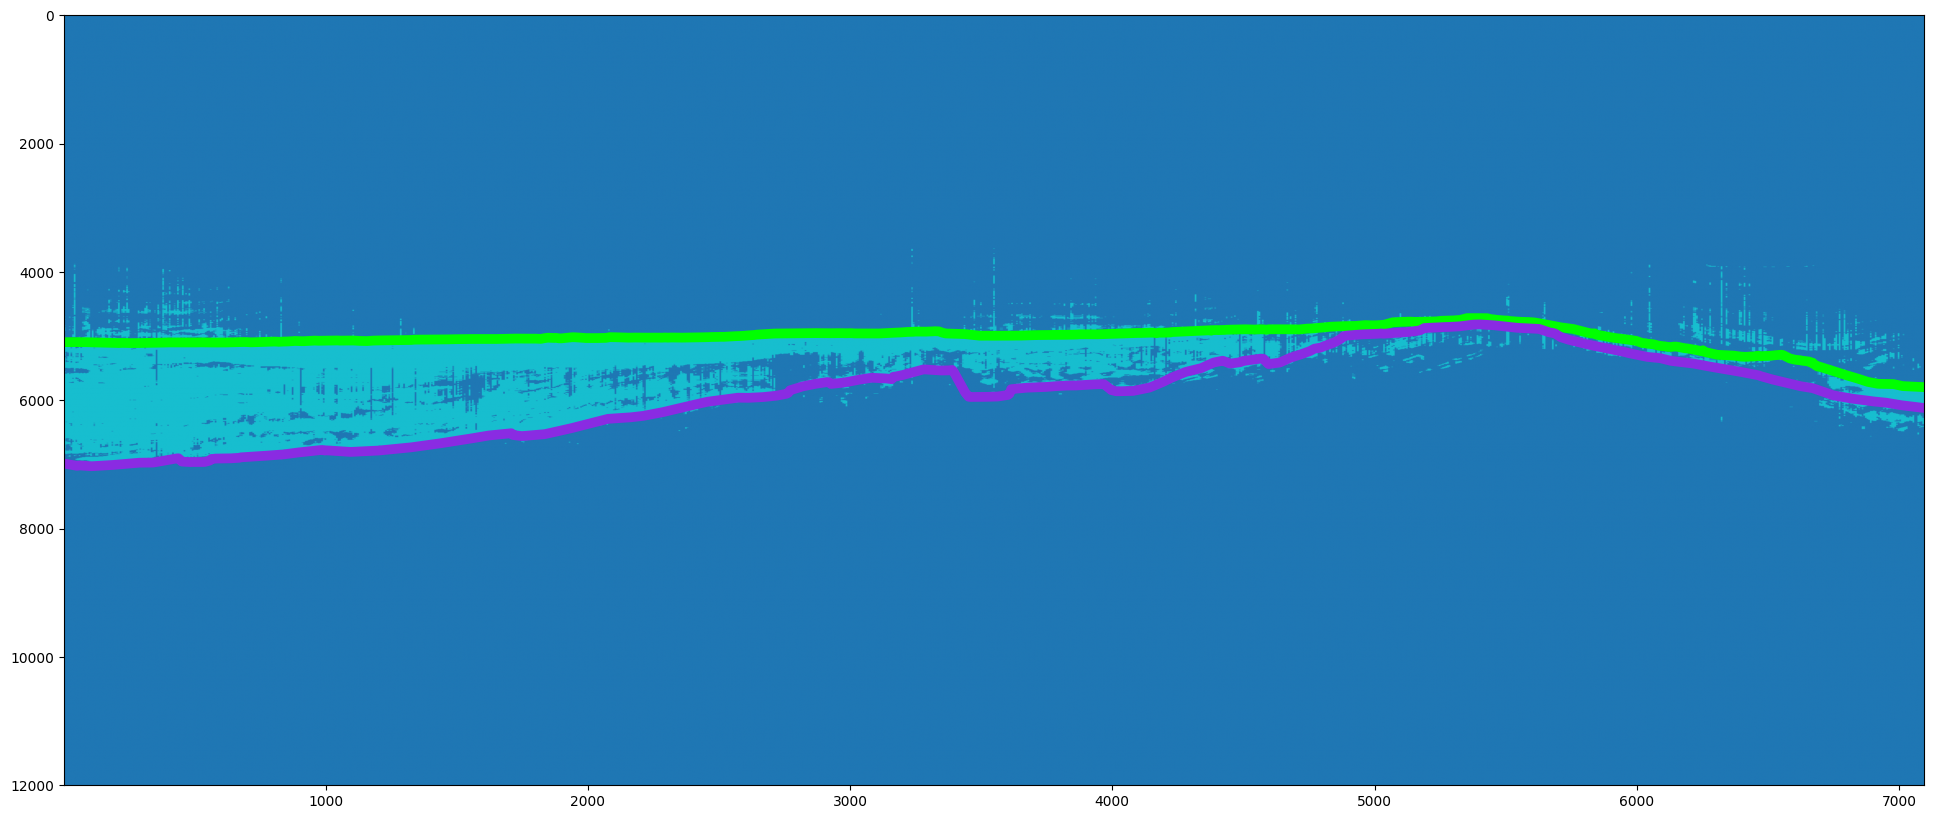

In [10]:
for obj in sessao_controle_Vittor:
    plot_VJ(obj, obj.yhat, color = 'tab10', linhas = True)
    compute_metrics(obj.segmentado.ravel(), obj.yhat.ravel())

for obj in sessao_controle_Fernanda:
    plot_Fernanda(obj, obj.yhat, color = 'tab10', linhas = True)
    compute_metrics(obj.segmentado.ravel(), obj.yhat.ravel())

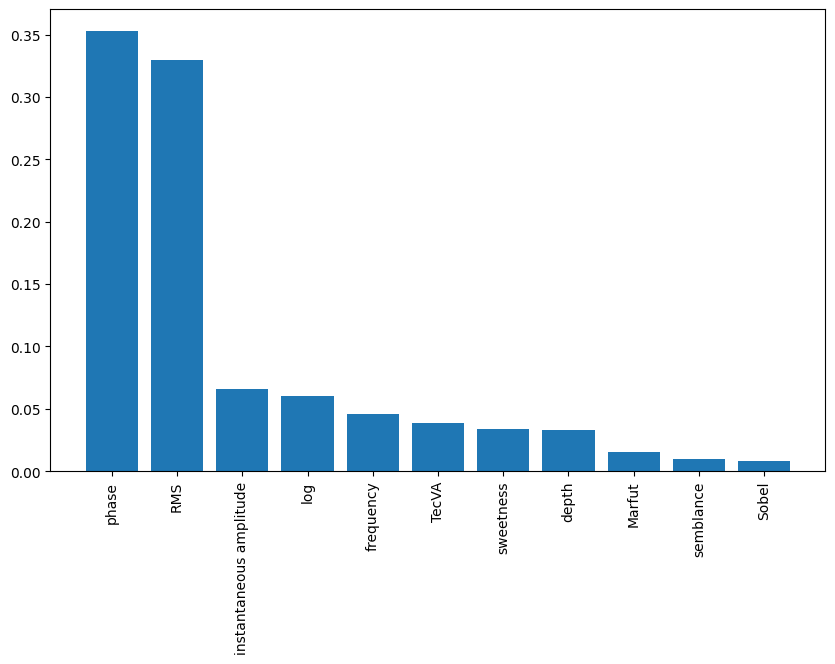

In [11]:
# Calculate feature importances
feature_names = [
    'amplitude', 
    'instantaneous amplitude', 'phase', 'frequency', 'sweetness',
    'log',
    'semblance', 'Sobel', 'Marfut',
    'depth', # yy
    'TecVA', 'RMS',
    'Velocity',
]

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize = (10, 6))
# plt.title("Feature importances with max_depth")
plt.bar(range(n_features-1), importances[indices][:-1])
plt.xticks(range(n_features-1), np.array(feature_names)[indices][:-1], rotation = 90)
plt.show()
# print ('importances for max_depth = ')
# print (importances[indices])